---
title: "Análise de Marketing"
format:
  html:
    code-fold: true
    code-tools: true
---

# **Objetivos do Estudo de Caso**
* Dados: Os dados foram retirados do módulo 4 do curso Power BI para Data Science da Data Science Academy.
* A proposta do presente estudo é aprofundar análises que foram feitas no respectivo curso de BI, agora utilizando Python para tais tarefas.
* Este estudo busca responder como características demográficas, canais de venda e campanhas influenciam o gasto total do cliente, além de prever esse gasto para apoiar decisões estratégicas de marketing.
* Dessa forma, busca-se elucidar o departamento de Marketing acerca das seguintes questões:
    1. Qual o impacto que cada característica do cliente tem sobre os gastos?
        1.1 Totais
        1.2 Por Categoria
    2. Há como estabelecer uma previsão, dadas as características do consumidor, do quanto será o seu gasto total?
    3. Qual o perfil de cliente em cada meio de canais de vendas.
    4. As campanhas de vendas foram efetivas? Qual delas foi a mais e a menos efetiva?

In [1]:
# Importando as bibliotecas necessarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import unicodedata

In [2]:
# Carregando a base de dados de uma planilha em Excel e visualizando os principais dados
df = pd.read_excel('dados_marketing.xlsx')
df.head(10)

,ID,Ano Nascimento,Escolaridade,Estado Civil,Salario Anual,Filhos em Casa,Adolescentes em Casa,Data Cadastro,Dias Desde Ultima Compra,Gasto com Eletronicos,...,Numero de Compras via Catalogo,Numero de Compras na Loja,Numero Visitas WebSite Mes,Compra na Campanha 1,Compra na Campanha 2,Compra na Campanha 3,Compra na Campanha 4,Compra na Campanha 5,Comprou,Pais
0,2795,1958,Mestrado,Solteiro,30523.0,2,1,2020-01-07,0,5,...,0,2,7,0,0,0,0,0,0,Chile
1,2285,1954,Mestrado,Casado,36634.0,0,1,2023-12-05,0,213,...,2,5,7,0,0,0,0,0,0,Espanha
2,115,1966,Mestrado,Solteiro,43456.0,0,1,2023-02-03,0,275,...,1,8,5,0,0,0,0,0,0,Argentina
3,10470,1979,Mestrado,Solteiro,40662.0,1,0,2023-05-03,0,40,...,1,3,4,0,0,0,0,0,0,Alemanha
4,4065,1976,Doutorado,Solteiro,49544.0,1,0,2020-11-02,0,308,...,1,8,7,0,0,0,0,0,0,Estados Unidos
5,10968,1969,Curso Superior,Solteiro,57731.0,0,1,2022-04-11,0,266,...,8,6,6,0,0,0,0,0,0,Argentina
6,5985,1965,Mestrado,Solteiro,33168.0,0,1,2022-12-10,0,80,...,1,4,7,0,0,0,0,0,0,Estados Unidos
7,5430,1956,Curso Superior,Casado,54450.0,1,1,2022-04-09,0,454,...,2,8,8,0,0,0,0,0,0,Estados Unidos
8,8432,1956,Curso Superior,Casado,54450.0,1,1,2022-04-09,0,454,...,2,8,8,0,0,0,0,0,0,Estados Unidos
9,453,1956,Doutorado,Divorciado,35340.0,1,1,2021-07-06,1,27,...,0,3,5,0,0,0,0,0,0,Estados Unidos


In [3]:
# Analisando o DF e corrigindo possiveis problemas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ID                              2000 non-null   int64         
 1   Ano Nascimento                  2000 non-null   int64         
 2   Escolaridade                    2000 non-null   object        
 3   Estado Civil                    2000 non-null   object        
 4   Salario Anual                   1981 non-null   float64       
 5   Filhos em Casa                  2000 non-null   int64         
 6   Adolescentes em Casa            2000 non-null   int64         
 7   Data Cadastro                   2000 non-null   datetime64[ns]
 8   Dias Desde Ultima Compra        2000 non-null   int64         
 9   Gasto com Eletronicos           2000 non-null   int64         
 10  Gasto com Brinquedos            2000 non-null   int64         
 11  Gast

In [4]:
# Transformando as colunas para o formato snake_case, garantindo compatibilidade com outras bibliotecas
def padronizar_colunas(df):
    new_cols = []
    for col in df.columns:
        # 1. Normaliza unicode para remover acentos
        c = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        # 2. Deixa minúsculo
        c = c.lower()
        # 3. Troca espaços por underline
        c = c.replace(' ', '_')
        # 4. Remove caracteres que não sejam letras, números ou underline (limpeza extra)
        c = c.replace('.', '').replace('-', '_')
        new_cols.append(c)
    
    df.columns = new_cols
    return df

# Aplicando ao dataset
df = padronizar_colunas(df)

# Verificando o resultado
df.columns

Index(['id', 'ano_nascimento', 'escolaridade', 'estado_civil', 'salario_anual',
       'filhos_em_casa', 'adolescentes_em_casa', 'data_cadastro',
       'dias_desde_ultima_compra', 'gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario',
       'numero_de_compras_com_desconto', 'numero_de_compras_na_web',
       'numero_de_compras_via_catalogo', 'numero_de_compras_na_loja',
       'numero_visitas_website_mes', 'compra_na_campanha_1',
       'compra_na_campanha_2', 'compra_na_campanha_3', 'compra_na_campanha_4',
       'compra_na_campanha_5', 'comprou', 'pais'],
      dtype='object')

* A transformação das colunas para o snake_case se dá devido a compatibilidade com outros bibliotecas, tais como a statsmodels, do qual necessita estar nesse formato, dessa forma colocar as colunas no devido formato é uma boa prática
* Além disso, o código acima aplicado ao df original garante uma escalabilidade, bem como que o código não seja quebrado caso o marketing enviase,por exemplo, outro arquivo Excel
* Ademais, há um arquivo extremamente destoante que é o salario anual maximo de 666666.00 que parace ser um erro de digitação ou exportação do banco de dados.

In [5]:
# Limpando observações que são possiveis erros
indices_nascimento = df[df['ano_nascimento'] < 1920].index
print("Observações não congruentes")
print(df['ano_nascimento'].loc[indices_nascimento])

Observações não congruentes
513    1893
827    1899
Name: ano_nascimento, dtype: int64


* *Como parece ser pouco provavel que há algum cliente com mais de 100 anos tais observações seram excluidas, juntamente da observação com o salario anual de 666.666*

In [6]:
df = df.drop(indices_nascimento)

In [7]:
indice_salario = df[df['salario_anual'] == 666666].index
print(f"Indices encontrados para exclusão: {indice_salario}")
df = df.drop(indice_salario)
df.info()


Indices encontrados para exclusão: Index([527], dtype='int64')
<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              1997 non-null   int64         
 1   ano_nascimento                  1997 non-null   int64         
 2   escolaridade                    1997 non-null   object        
 3   estado_civil                    1997 non-null   object        
 4   salario_anual                   1978 non-null   float64       
 5   filhos_em_casa                  1997 non-null   int64         
 6   adolescentes_em_casa            1997 non-null   int64         
 7   data_cadastro                   1997 non-null   datetime64[ns]
 8   dias_desde_ultima_compra        1997 non-null   int64         
 9   gasto_com_eletronicos           1997 non-null   int64         
 10  gasto_com_brin

# **1 - Caracteristicas do Cliente e Gastos Totais**

# **1.1 Gastos Totais**

In [8]:
# Criando um Data Frame com as colunas necessarias para avaliação
df_clientes = df[['id','ano_nascimento','escolaridade','estado_civil','salario_anual','filhos_em_casa','adolescentes_em_casa', 'data_cadastro', 
        'dias_desde_ultima_compra', 'gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario','pais']].copy()

In [9]:
# Criando uma coluna com o gasto total por cliente
Soma_Gastos = ['gasto_com_eletronicos','gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades','gasto_com_alimentos', 'gasto_com_vestuario']
df_clientes['gasto_total'] = df[Soma_Gastos].sum(axis = 1)

## Gastos Totais por Escolaridade

In [10]:
# Perfil de gastos totais por Escolaridade
tabela_escolaridade = df_clientes.groupby('escolaridade').agg(
    Gasto_Total=('gasto_total', 'sum'),
    Quantidade_por_Escolaridade = ('gasto_total', 'count'),
    Gasto_Médio_por_Escolaridade = ('gasto_total', 'mean'),
)
# Ordenando os valores por Gasto Total
tabela_escolaridade = tabela_escolaridade.sort_values('Gasto_Total',ascending = False)

print('Gastos Totais por Escolaridade:') 

# Criação da média total entre os grupos escolares
media_geral = tabela_escolaridade['Gasto_Total'].mean()
print(f"Média Geral por Escolaridade: {media_geral}")
visualização = {
    'Gasto_Total': "Gasto Total",
    'Quantidade_por_Escolaridade': 'Quantidade por Escolaridade',
    'Gasto_Médio_por_Escolaridade': 'Gasto Médio por Escolaridade'
}
# Visualização dos resultados
tabela_escolaridade.rename(columns=visualização)\
    .rename_axis('Escolaridade')\
    .style.format({
    'Gasto_Total':'R$ {:,.2f}',
    'Gasto_Médio_por_Escolaridade':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos Totais por Escolaridade:
Média Geral por Escolaridade: 240586.8


,Gasto Total,Quantidade por Escolaridade,Gasto Médio por Escolaridade
Escolaridade,,,
Curso Superior,617551,999,618.169169
Doutorado,282394,436,647.692661
Mestrado,207657,337,616.192878
Segundo Grau,92326,176,524.579545
Primeiro Grau,3006,49,61.346939


* Dessa forma, o maior faturamento advém daqueles que possuem Curso superior, bem como as pessoas com curso superior são as que mais representam a nossa base de clientes.
* Entretanto, as pessoas com Doutorado e Mestrado apesar de gastarem menos em valores absolutos, uma vez que representam uma porcentagem menor na base de clientes, apresentam um **gasto médio superior e próximo do gasto médio das pessoas com curso superior.**
* Dessa forma, tais pessoas com essa escolaridade podem buscar **produtos com ticket médio maior**, logo sendo mais suscetíveis provavelmente a receberam ofertas de produtos com maior valor agregado.
* Também nos levanta a seguinte dúvida: as pessoas com maior escolaridade possuem uma renda média maior que as outras? A média reflete bem a base de clientes ou há muita dispersão?
* A esperança para essas perguntas é que sejam, uma vez que é bem fundamentado na teoria econômica que maiores graus de escolaridade impactam no salário médio de um indivíduo.

In [11]:
# Tabela Renda média por escolaridade
tabela_renda = df_clientes.groupby('escolaridade').agg(
    Salario_medio = ('salario_anual', 'mean'),
    Moda_Salario  = ('salario_anual', lambda x: x.mode()[0]),
    Mediana = ('salario_anual', 'median'),
    Qtd_Salario_Superior_60k = ('salario_anual', lambda x: (x>60000).sum())
)

# Ordenando os valores por Salário Médio
tabela_renda = tabela_renda.sort_values('Salario_medio',ascending = False)

print("Gastos por Quantidade de Filhos em Casas")
# Criação da média total entre os grupos escolares
media_geral = tabela_renda['Salario_medio'].mean()

print(f"Sálario Médio Geral por Escolaridade: {media_geral}")
# Criando dicionario para alteração do nome das colunas
visualização = {
    'Salario_medio': 'Sálario Médio',
    'Moda_Salario': 'Moda Sálario',
    'Mediana': 'Mediana',
    'Qtd_Salario_Superior_60k': 'Qtd Sálarios Superiores a 60k'
}
# Visualização dos resultados
tabela_renda.rename(columns=visualização)\
    .rename_axis('Escolaridade')\
    .style.format({
    'Salario_medio':'R$ {:,.2f}',
    'Moda_Salario':'R$ {:,.2f}',
    'Mediana':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos por Quantidade de Filhos em Casas
Sálario Médio Geral por Escolaridade: 46002.23476541518


,Sálario Médio,Moda Sálario,Mediana,Qtd Sálarios Superiores a 60k
Escolaridade,,,,
Doutorado,55435.986079,35860.000000,"R$ 54,880.00",173
Mestrado,53226.271084,46098.000000,"R$ 51,044.50",120
Curso Superior,52051.751766,7500.000000,"R$ 52,332.00",390
Segundo Grau,49483.491429,7500.000000,"R$ 49,514.00",64
Primeiro Grau,19813.673469,7500.000000,"R$ 20,425.00",0


* Podemos notar que o maior salário médio é justamente de pessoas com Doutorado, seguidos por Mestrado e Curso Superior
* Entretanto, nota-se que **há mais pessoas com mestrado ganhando um valor superior em quantidade do que pessoas com doutorado**, uma vez que sua moda é maior.
* Além disso, é provável que os dados para os salários anuais **não sigam uma distribuição normal**, uma vez que há diferenças significativas entre a média e a moda.
* Entretanto, tal característica é esperada, uma vez que, normalmente, as modas salariais tendem a ser mais baixas que a média, pois espera-se que há mais pessoas ganhando salários menores que a média no geral também em relatórios do IBGE, caracterizando tais observações como não-paramétricas.

In [12]:
# Teste de Normalidade para a variavel Salario Anual
df_limpo = df.dropna()
stat_salario, p_normal = stats.shapiro(df_limpo['salario_anual'])
print(f"Estatisticas de teste: Estatística={stat_salario:.4f}, p-valor={p_normal:.4f}")
if p_normal > 0.05:
    print("Conclusão: Não rejeitamos H0 (dados parecem normais)")
else:
    print("Conclusão: Rejeitamos H0 (dados não parecem normais)")

Estatisticas de teste: Estatística=0.9759, p-valor=0.0000
Conclusão: Rejeitamos H0 (dados não parecem normais)


* Como esperado, os dados para os salários anuais se demonstraram não apresentar normalidade, o que pode tornar a medida média enviesada.
* Entretanto, apesar disso, é comum na literatura econômica a utilização do salário médio, seja anual ou mensal, para avaliar a renda dos indivíduos por diversas categorias.
* **Com isso, é orientada a área de marketing a ter uma certa homogeneidade relacionada à escolaridade**, com os percentuais relativos de pessoas que recebem mais de 60mil anuais girando em torno de 39% nas esferas de Doutorado, Mestrado e Curso Superior com base em seus totais.
* Além disso, **não há grandes diferenças que se mostram significativas com base nas diferenças salariais entre pessoas com curso superior, mestrado e doutorado**.

## Gastos Totais por Filhos e Adolescentes em Casa

In [13]:
# Tabela Gastos Totais por Filhos em Casa
tabela_filhos = df_clientes.groupby('filhos_em_casa').agg(
    Gastos_Totais = ('gasto_total','sum'),
    Qtd_de_Clientes =  ('gasto_total','count'),
    Gasto_Médio = ('gasto_total','mean'),
)
# Ordenando os valores por Gasto Total
tabela_filhos = tabela_filhos.sort_values('Gastos_Totais',ascending = False)

print("Gastos por Quantidade de Filhos em Casas")

# Criação da média total entre a quantidade de filhos em casa
media_geral = tabela_filhos['Gastos_Totais'].mean()
print(f"Média Geral por Filhos: {media_geral}")
# Criando dicionario para alteração do nome das colunas
visualização = {
    'Gastos_Totais': 'Gastos Totais',
    'Qtd_de_Clientes': 'Qtd de Clientes',
    'Gasto_Médio': 'Gasto Médio'
}
#Visualização dos resultados
tabela_filhos.rename(columns=visualização)\
    .rename_axis('Quantidade de Filhos em Casa')\
    .style.format({
    'Gastos_Totais':'R$ {:,.2f}',
    'Gasto_Médio':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos por Quantidade de Filhos em Casas
Média Geral por Filhos: 400978.0


,Gastos Totais,Qtd de Clientes,Gasto Médio
Quantidade de Filhos em Casa,,,
0,1031239,1142,903.011384
1,165711,816,203.077206
2,5984,39,153.435897


* Nota-se que a **maior parte dos nossos clientes não possui filhos em casa**, bem como são eles os responsáveis por maiores gastos totais, com seus gastos médios superando em muito os gastos das pessoas que possuem 1 ou 2 filhos em casa.
* Isso pode evidenciar que a maior parte dos nossos clientes não tem interesse em gastar com brinquedos, por exemplo, além disso, eles **possuem então uma restrição orçamentária maior para gastar com bens para utilidade própria**, uma vez que não possuem despesas atreladas a filhos morando juntos dos mesmos.
* Porém, temos que avaliar também se essas pessoas possuem adolescentes em suas casas.

In [14]:
# Tabela Gastos Totais por Adolecentes em Casa
tabela_adolescentes = df_clientes.groupby('adolescentes_em_casa').agg(
    Gasto_Total = ('gasto_total','sum'),
    Qtd_de_clientes = ('gasto_total','count'),
    Gasto_Médio = ('gasto_total','mean')
)

# Ordenando a tabela pelo gasto total
tabela_adolescentes = tabela_adolescentes.sort_values('Gasto_Total', ascending = False)

print("Gastos por Quantidade de Adolecentes em Casas")

# Criação da média total entre a quantidade de adolescentes em casa
media_geral = tabela_adolescentes['Gasto_Total'].mean()
print(f"Média Geral por Adolecentes: {media_geral}")

# Visualização dos resultados 
tabela_adolescentes.rename(columns=visualização)\
    .rename_axis('Qtd de Adolescentes em Casa')\
    .style.format({
    'Gasto_Total':'R$ {:,.2f}',
    'Gasto_Médio':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos por Quantidade de Adolecentes em Casas
Média Geral por Adolecentes: 400978.0


,Gasto_Total,Qtd_de_clientes,Gasto Médio
Qtd de Adolescentes em Casa,,,
0,"R$ 711,883.00",1034,688.474855
1,"R$ 468,727.00",921,508.932682
2,"R$ 22,324.00",42,531.523810


* Com base nisso, também vemos que **a maior parte dos nossos clientes não possui adolescentes em casa**, o que reforça a ideia de termos clientes com uma **restrição orçamentária maior para gastar com bens para utilidade própria.**
* Ademais, é instruído ao departamento de Marketing que se atente ao fato de que **clientes que possuem 1 adolescente em casa tendem a gastar mais se comparado com quem possui 1 filho em casa**.
* Isso mostra que pessoas com pelo menos 1 adolescente em casa gastam mais com os produtos da empresa se comparado àqueles que possuem um filho pequeno.

## Gastos Totais por Estado Civil

In [15]:
# Tabela Gastos Totais por Estado Civil
tabela_estado_civil = df_clientes.groupby('estado_civil').agg(
    Gasto_Total = ('gasto_total', 'sum'),
    Qtd_de_Cliente = ('gasto_total', 'count'),
    Gasto_Médio = ('gasto_total', 'mean')
)

# Ordenando a tabela pelo gasto total
tabela_estado_civil = tabela_estado_civil.sort_values('Gasto_Total', ascending = False)

print("Gastos totais por Estado Civil do Cliente")

# Criação da média total pelo estado civil do cliente
media_geral = tabela_estado_civil['Gasto_Total'].mean()
print(f"Média Geral por Estado Civil: {media_geral}")

# Visualização dos resultados
tabela_estado_civil.rename(columns=visualização)\
    .rename_axis('Estado Civil')\
    .style.format({
    'Gasto_Total':'R$ {:,.2f}',
    'Gasto_Médio':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos totais por Estado Civil do Cliente
Média Geral por Estado Civil: 400978.0


,Gasto_Total,Qtd_de_Cliente,Gasto Médio
Estado Civil,,,
Solteiro,"R$ 707,493.00",1196,591.549331
Casado,"R$ 317,254.00",521,608.932821
Divorciado,"R$ 178,187.00",280,636.382143


* Dessa forma, podemos notar que a maior parte dos nossos clientes são solteiros, entretanto, outro escopo relevante é formado pelos casados.
* O grupo de Casados também compõe o segundo maior grupo, bem como possui um gasto médio maior se comparado com o grupo dos solteiros.
* **Ademais, o grupo que possui um gasto médio maior, olhando para o estado civil, é o grupo de divorciados.**

## Gastos Totais por Geração

In [16]:
# Criando uma coluna com idade
df_clientes['idade'] = 2025 - df_clientes['ano_nascimento'] # Coluna Idade
# Criando uma coluna com faixa etária geracional
# Criação da regra de négocio
def definir_geracao(ano):
    if ano < 1946:
        return 'Veteranos'
    elif ano <= 1964:
        return 'Baby Boomers'
    elif ano <= 1980:
        return 'Geração X'
    elif ano <= 1996:
        return 'Millennials'
    else:
        return 'Geração Z'

# Criação da coluna com a geração de cada cliente
df_clientes['geracao'] = df_clientes['ano_nascimento'].apply(definir_geracao)

In [17]:
# Criação dos gastos totais por geração
tabela_geracao = df_clientes.groupby('geracao').agg(
    Gasto_Total = ('gasto_total','sum'),
    Qtd_Clientes = ('gasto_total','count'),
    Gasto_Médio = ('gasto_total','mean'),
)

# Ordenamento pelo Gasto Total
tabela_geracao = tabela_geracao.sort_values('Gasto_Total', ascending = False)

print("Gastos totais por Geração")

# Criação da média total pela geração do cliente
media_geral = tabela_geracao['Gasto_Total'].mean()
print(f"Média Geral por Geração: {media_geral}")

# Visualização dos resultados
tabela_geracao.rename(columns=visualização)\
    .rename_axis('Geração')\
    .style.format({
    'Gasto_Total':'R$ {:,.2f}',
    'Gasto_Médio':'R$ {:,.2f}'}).background_gradient(cmap='RdYlGn')

Gastos totais por Geração
Média Geral por Geração: 300733.5


,Gasto_Total,Qtd_Clientes,Gasto Médio
Geração,,,
Geração X,"R$ 502,836.00",951,528.744479
Baby Boomers,"R$ 479,416.00",678,707.103245
Millennials,"R$ 195,281.00",346,564.395954
Veteranos,"R$ 25,401.00",22,1154.590909


* Dessa forma, a maior parte de **nossos clientes consiste na Geração X com 952 clientes**, e são eles que apresentaram o maior gasto total
* Entretanto, o **gasto médio mais representativo,** dado a quantidade de clientes, se deu **pela geração Baby Boomers** ou seja, aqueles nascidos entre 1964 e 1980, com um gasto médio de cerca de 707 por cliente.
* Ademais, nota-se um número baixo de clientes da geração de veteranos, porém com gasto médio por cliente alto, o que pode nos levantar a hipótese de que tal geração tenha mais renda, o que implica em gasto total maior.
* Nota-se também a **ausência** de clientes da geração Z
* **Tais informações são relevantes para entender o perfil do cliente predominante da empresa**, uma vez que sua geração pode nos dar informações sobre as principais tendências dos mesmos, bem como suas preferências.

## Gastos Totais por País

In [18]:
# Criação da tabela dos gastos totais por País do cliente
tabela_pais = df_clientes.groupby('pais').agg(
    Gasto_Total = ('gasto_total', 'sum'),
    Qtd_Clientes = ('gasto_total', 'count'),
    Gasto_Medio = ('gasto_total', 'mean'),
)

# Ordenando os valores pelo gasto total
tabela_pais = tabela_pais.sort_values('Gasto_Total', ascending = False)

print("Gastos Totais por País")

# Criação da média total pelo gasto total por país
media_geral = tabela_pais['Gasto_Total'].mean()
print(f"Média Geral por País: {media_geral}")

# Visualização dos resultados
tabela_pais.rename(columns=visualização)\
    .rename_axis('País')\
    .style.format({
    'Gasto_Total':'R$ {:,.2f}',
    'Gasto_Medio':'R$ {:,.2f}'
}).background_gradient(cmap='RdYlGn')

Gastos Totais por País
Média Geral por País: 171847.7142857143


,Gasto_Total,Qtd_Clientes,Gasto_Medio
País,,,
Estados Unidos,"R$ 593,121.00",976,R$ 607.71
Espanha,"R$ 185,561.00",301,R$ 616.48
Chile,"R$ 150,390.00",245,R$ 613.84
Brasil,"R$ 81,154.00",145,R$ 559.68
Argentina,"R$ 72,053.00",133,R$ 541.75
Alemanha,"R$ 60,568.00",104,R$ 582.38
Portugal,"R$ 60,087.00",93,R$ 646.10


* **A maior parte dos clientes está nos Estados Unidos,** sendo eles o grupo mais representativo da empresa, assim um grupo importante.
* O país com maior gasto médio é Portugal, dessa forma podendo ser um sinal de que clientes no país requisitam produtos de maior valor agregado
* Há também uma considerável representatividade de nossos clientes na América Latina (Chile, Brasil e Argentina), com 523 clientes.

## Classificação dos clientes por agrupamentos

Para a classificação dos clientes em segmentos, será adotado o método K-Means, uma vez que queremos agrupar os clientes. Dessa forma o algoritmo agrupa clientes parecidos em um mesmo grupo ao passo que os distintos são agrupados em outros. O K-Means é amplamente utilizado em marketing devido a criação de segmentos de clientes.

Para a definição da quantidade de clusters sera utilizado o metodo de Elbow juntamente com o Silhouette Score que consiste em selecionar o numero de cluster com base naquele que faz com que o erro não caia muito. Bem como, analisar o silhoutte score que apresenta um valor alto

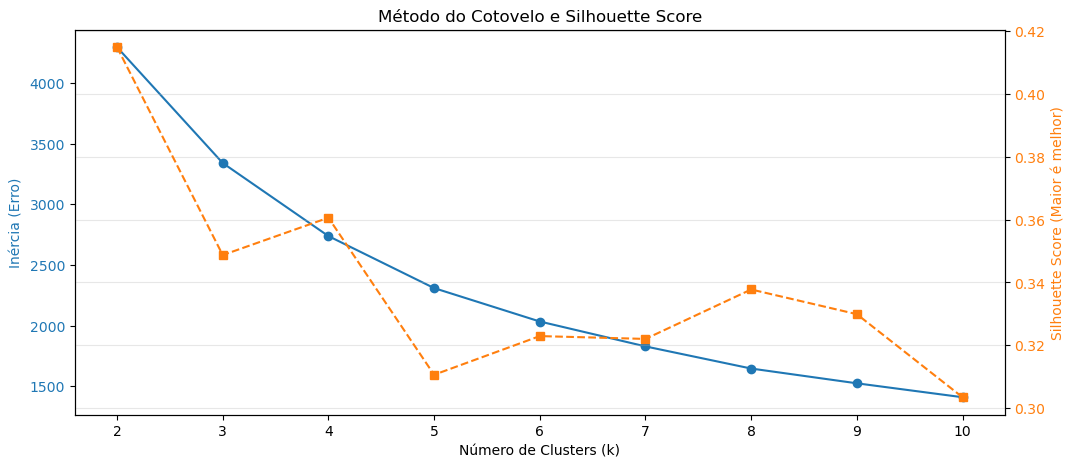

In [19]:
# Criação do gráfico do Elbow Method e Silhouette Score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Preparação dos dados
colunas_cluster = ['salario_anual', 'gasto_total', 'idade', 'filhos_em_casa']
df_foco = df_clientes[colunas_cluster].dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_foco)

# --- APLICANDO O MÉTODO DO COTOVELO ---
inercia = []
silhouette_avg = []
range_k = range(2, 11) # Vamos testar de 2 a 10 grupos

for k in range_k:
    # Roda o K-Means para k grupos
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(df_scaled)
    
    # Salva o erro (Inércia)
    inercia.append(kmeans_teste.inertia_)
    
    # Salva a qualidade da separação (Silhouette)
    cluster_labels = kmeans_teste.labels_
    silhouette_avg.append(silhouette_score(df_scaled, cluster_labels))

# --- PLOTANDO OS GRÁFICOS ---
fig, ax1 = plt.subplots(figsize=(12, 5))

# Gráfico 1: Cotovelo (Inércia)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Erro)', color='tab:blue')
ax1.plot(range_k, inercia, marker='o', color='tab:blue', label='Inércia')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Método do Cotovelo e Silhouette Score')

# Gráfico 2: Silhouette (Eixo secundário)
ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score (Maior é melhor)', color='tab:orange')  
ax2.plot(range_k, silhouette_avg, marker='s', linestyle='--', color='tab:orange', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.grid(True, alpha=0.3)
plt.show()

Com base no Elbow Method e Silhouette Score o número de clusters ideal para o conjunto de dados é k = 4. Uma vez que, a linha correspondente ao Elbow não possui um decaimento muito abrupto de 4 para 5 e de 5 para 6, bem como ele apresenta melhor valor para o Silhouette Score, dessa forma adotando uma medida mais conservadora, e optando por um menor número de clusters.

In [20]:
# Criação dos segmentos de cada cliente
from sklearn.cluster import KMeans
# 1. Seleção das Variáveis de Comportamento (O "DNA" do cliente)
df_foco = df_clientes[colunas_cluster].dropna()

# 2. Padronização (Obrigatório para o K-Means não viciar no Salário que é um numero grande)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_foco)

# 3. Criando os Clusters por k = 4 perfis de clientes
kmeans = KMeans(n_clusters=4, random_state=42)
df_foco['Cluster'] = kmeans.fit_predict(df_scaled)

# Trazendo essa informação para o DataFrame principal
df_clientes.loc[df_foco.index, 'Perfil_Cluster'] = df_foco['Cluster']

# 4. Agrupando para descobrir quem é quem
# Função lambda para pegar a 'Moda' (o valor que mais aparece no texto)
moda = lambda x: x.mode()[0] if not x.mode().empty else "N/A"

tabela_perfis = df_clientes.groupby('Perfil_Cluster').agg({
    'gasto_total': 'mean',          # Média de gasto
    'salario_anual': 'mean',        # Média de salário
    'idade': 'mean',                # Idade média
    'escolaridade': moda,           # Escolaridade predominante
    'estado_civil': moda,           # Estado Civil predominante
    'id': 'count'                   # Tamanho do grupo
}).sort_values('gasto_total', ascending=False) # Ordena dos com maiores gastos para os menores

# Criando Dicionario para exibição das colunas
nomes_exibição = {
    'gasto_total': 'Gasto Médio Total',
    'salario_anual': 'Salário Médio Anual',
    'idade': 'Média de Idade',
    'escolaridade': 'Moda da Escolaridade',
    'estado_civil': 'Moda do Estado Civil',
    'id': 'Número de Clientes no Segmento'
}

# Estilização
tabela_perfis.rename(columns=nomes_exibição)\
                .rename_axis('Segmentação do Cliente') \
                .style.background_gradient(cmap='Greens', subset=['Gasto Médio Total', 'Salário Médio Anual']) \
                .format({'Gasto Médio Total': 'R$ {:,.2f}', 
                        'Salário Médio Anual': 'R$ {:,.2f}', 
                        'Média de Idade': '{:.0f} anos'})

,Gasto Médio Total,Salário Médio Anual,Média de Idade,Moda da Escolaridade,Moda do Estado Civil,Número de Clientes no Segmento
Segmentação do Cliente,,,,,,
1.000000,"R$ 1,348.15","R$ 75,206.02",56 anos,Curso Superior,Solteiro,616
0.000000,R$ 453.59,"R$ 50,620.57",64 anos,Curso Superior,Solteiro,478
3.000000,R$ 236.80,"R$ 45,502.18",60 anos,Curso Superior,Solteiro,397
2.000000,R$ 108.70,"R$ 29,137.36",45 anos,Curso Superior,Solteiro,487


Como podemos ver agora quais clusters são os que possuem mais gasto médio total podemos renomear os mesmos também de acordo com segmento. Será utilizado a escala com base em metais, bem comum em projetos de marketing, bem como em alguns jogos de videogames, sendo assim quanto mais "raro" o metal maior é o gasto do cliente no nosso caso.

In [21]:
# Alterando o nome dos clusters/segmentação dos clientes
nome_clusters = {
    1: 'Platinum',
    0: 'Gold',
    3: 'Silver',
    2: 'Bronze'
}
#Criando colunas com nomes
df_clientes['Nome_Cluster'] =  df_clientes['Perfil_Cluster'].map(nome_clusters)

# Copiando código da célula acima alterando o agrupamento da coluna Perfil_Cluster para Nome_Clusters
tabela_perfis = df_clientes.groupby('Nome_Cluster').agg({
    'gasto_total': 'mean',          # Média de gasto
    'salario_anual': 'mean',        # Média de salário
    'idade': 'mean',                # Idade média
    'escolaridade': moda,           # Escolaridade predominante
    'estado_civil': moda,           # Estado Civil predominante
    'id': 'count'                   # Tamanho do grupo
}).sort_values('gasto_total', ascending=False) # Ordena dos com maiores gastos para os menores

# Criando Dicionario para exibição das colunas
nomes_exibição = {
    'gasto_total': 'Gasto Médio Total',
    'salario_anual': 'Salário Médio Anual',
    'idade': 'Média de Idade',
    'escolaridade': 'Moda da Escolaridade',
    'estado_civil': 'Moda do Estado Civil',
    'id': 'Número de Clientes no Segmento'
}

# Estilização
tabela_perfis.rename(columns=nomes_exibição)\
                .rename_axis('Segmentação do Cliente') \
                .style.background_gradient(cmap='Greens', subset=['Gasto Médio Total', 'Salário Médio Anual']) \
                .format({'Gasto Médio Total': 'R$ {:,.2f}', 
                        'Salário Médio Anual': 'R$ {:,.2f}', 
                        'Média de Idade': '{:.0f} anos'})


,Gasto Médio Total,Salário Médio Anual,Média de Idade,Moda da Escolaridade,Moda do Estado Civil,Número de Clientes no Segmento
Segmentação do Cliente,,,,,,
Platinum,"R$ 1,348.15","R$ 75,206.02",56 anos,Curso Superior,Solteiro,616
Gold,R$ 453.59,"R$ 50,620.57",64 anos,Curso Superior,Solteiro,478
Silver,R$ 236.80,"R$ 45,502.18",60 anos,Curso Superior,Solteiro,397
Bronze,R$ 108.70,"R$ 29,137.36",45 anos,Curso Superior,Solteiro,487


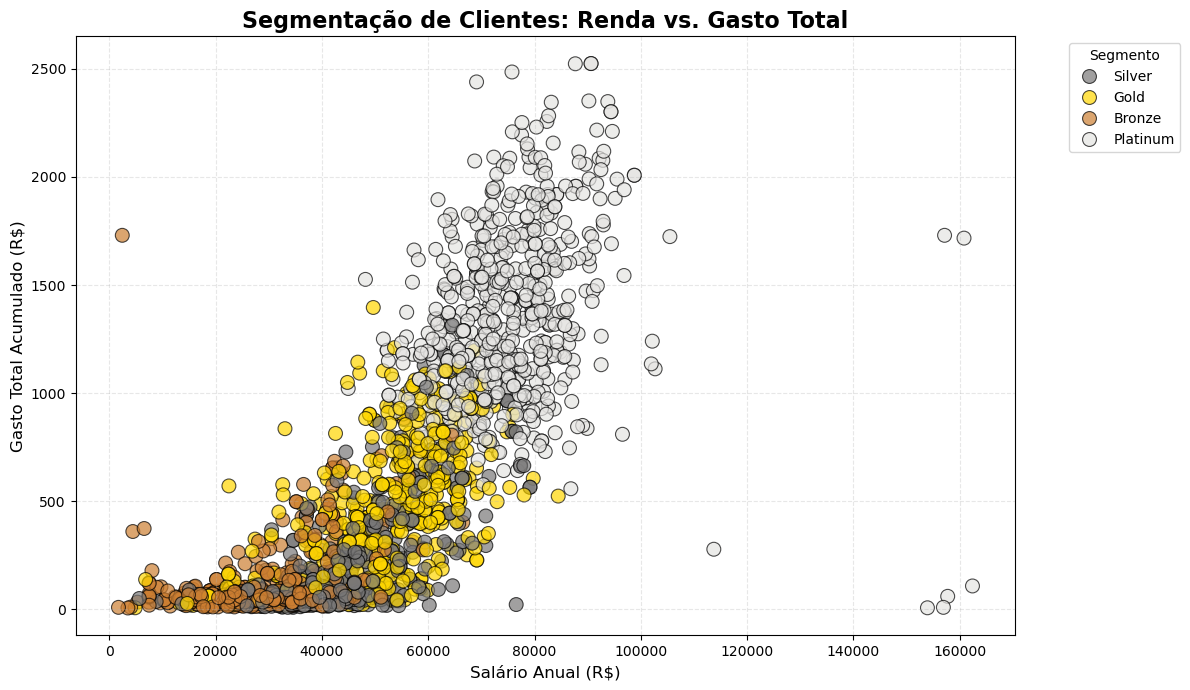

In [22]:
# Criando scatter plot
cores_metais = {
    'Platinum': '#E5E4E2',  # Platina 
    'Gold': '#FFD700',            # Dourado
    'Silver': "#797878",          # Prateado
    'Bronze': '#CD7F32'           # Bronze
}

plt.figure(figsize=(12,7))
# Gráfico
sns.scatterplot(
    data = df_clientes,
    x = 'salario_anual',
    y = 'gasto_total',
    hue='Nome_Cluster',
    palette=cores_metais,
    s=100,
    alpha= 0.7,
    edgecolor ='black'
)
# Titulos
plt.title('Segmentação de Clientes: Renda vs. Gasto Total', fontsize=16, fontweight='bold')
plt.xlabel('Salário Anual (R$)', fontsize=12)
plt.ylabel('Gasto Total Acumulado (R$)', fontsize=12)
# Melhorias na Legenda
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
# Grid
plt.grid(True, alpha=0.3, linestyle='--')
# Exibição
plt.tight_layout()

plt.show()

Com o gráfico podemos notar a relação positiva entre o salario anual com o gasto total, bem como no geral a segmentação dos clientes (determinado pelas cores) são efetivas, uma vez que expressão bem a segmentação dos clientes. Apesar da presença de alguns "Outliers" em cada segmento. por exemplo 4 clientes que possuem salarios anuais de 160 mil reais, mas com gastos totais acumulados próximos de 0.

## Conclusão Segmentação Clientes

Com base na segmentação, podemos notar algumas características importantes acerca da segmentação de nossos clientes, ademais deve-se atentar para alguns fatores:
A escolaridade e o estado civil correspondem à **Moda** de cada grupo, ou seja, qual o valor que mais aparece com base nos clientes no segmento. Com os outros valores representando a média da variável, como descrito.

De modo geral, vemos que em todos os grupos predomina-se a escolaridade de Curso Superior e pessoas Solteiras, bem como temos média de idade para todos os grupos altas, em torno da faixa de 45 anos a 64 anos. Tais resultados eram esperados, uma vez que em análises anteriores chegamos à conclusão de que a maior parte dos nossos clientes são justamente pessoas com Curso superior, Solteiras, sem filhos em casa e que pertencem às gerações X e Baby Boomers.

* O Segmento *Platinum* é composto por clientes que têm um gasto médio total de 1348 reais, bem como é o segmento formado por aqueles que têm rendas anuais médias consideravelmente altas para os dados de nossos clientes. Além disso, eles são o segmento mais populoso, com cerca de 616 clientes. Ademais, a maioria dos clientes possui Curso Superior (somente graduação) e são solteiros. Estes clientes podemos definir como **consumidores com renda alta, que possuem gastos médios altos, e com média de idade de 56 anos, sendo assim são consumidores que têm mais renda disponível para gastos.**
* O Segmento *Gold* é composto por clientes que possuem um gasto médio total bem menor se comparado ao grupo Platinum, com cerca de 453 reais, bem como possuem um salário médio anual mais próximo da média da amostra de cerca de R$ 50,620.57. Estes clientes podem ser definidos como **consumidores com renda média e que possuem um gasto médio menor, bem como tais clientes são ligeiramente mais velhos que o segmento Platinum, com média de idade de 64 anos.** Esse segmento é o 3 mais populoso da base de nossos clientes.
* O Segmento *Silver* é composto por clientes que possuem um gasto médio total ainda menor se comparado ao segmento Gold, entretanto eles possuem salários médios anuais parecidos com cerca de 5000 reais de diferença entre as duas médias. Estes clientes podem ser definidos como **consumidores mais parcimoniosos, pois mesmo que suas rendas anuais se aproximem do grupo Gold seus gastos não o fazem. Dessa forma, podemos dizer que podem ser clientes que possuem uma propensão marginal a consumir menor, e que provavelmente direcionem seu consumo para outros itens**. Ademais, este segmento é o menor dos 4 segmentos encontrados pelo algoritmo.
* O Segmento *Bronze* é composto por clientes que possuem tanto um gasto quanto um salário médio baixos se comparados aos outros clientes, ademais eles se distanciam bem do grupo Gold e Silver no que tange ao salário médio anual, dessa forma caracterizando como um grupo de renda mais baixa dentre todos. Estes clientes podem ser definidos como **consumidores com renda baixa e baixo consumo na nossa loja e que provavelmente têm gastos mais esporádicos conosco, ou seja, não são clientes assíduos**. Ademais, tal segmento é o segundo maior dentro de todos os quatro.

Dessa forma, nota-se também que o grupo Platinum é composto por clientes assíduos, com o grupo Gold tal informação sendo incerta e para os grupos Silver e Bronze sendo caracterizados também como clientes não assíduos em compras na loja.

# **1.2 - Gastos por categoria do produto**

In [23]:
tabela_gastos_por_categoria = df_clientes[['gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario']].sum().reset_index()

tabela_gastos_por_categoria = tabela_gastos_por_categoria.sort_values(0,ascending = False)
tabela_gastos_por_categoria

,index,0
0,gasto_com_eletronicos,607085
2,gasto_com_moveis,327702
5,gasto_com_vestuario,87029
3,gasto_com_utilidades,75055
4,gasto_com_alimentos,53588
1,gasto_com_brinquedos,52475


* Nota-se que a maior parte dos gastos se dá em eletronicos, entretanto pouco podemos dizer em volume, **sendo assim não podemos auferir qual categoria dos produtos vendem mais**
* Porém, podemos notar que a **maior parte da receita advém de eletronicos, móveis e vestuarios**. 

## Gastos Totais por Filhos e Adolescentes

In [24]:
# Criando tabela com a categoria dos gastos por quantidade de filhos em casa do cliente
tabela_filhos_c = df_clientes.groupby('filhos_em_casa')[['gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario']].sum().reset_index()
colunas_monetarias = ['gasto_com_eletronicos', 'gasto_com_brinquedos', 
                 'gasto_com_moveis', 'gasto_com_utilidades',
                 'gasto_com_alimentos', 'gasto_com_vestuario']
# Visualização dos resultados
tabela_filhos_c.style.background_gradient(cmap='Greens',subset=colunas_monetarias).format('R$ {:,.2f}', subset= colunas_monetarias)

,filhos_em_casa,gasto_com_eletronicos,gasto_com_brinquedos,gasto_com_moveis,gasto_com_utilidades,gasto_com_alimentos,gasto_com_vestuario
0,0,"R$ 519,202.00","R$ 45,497.00","R$ 287,843.00","R$ 64,677.00","R$ 46,252.00","R$ 67,768.00"
1,1,"R$ 84,643.00","R$ 6,689.00","R$ 38,592.00","R$ 10,075.00","R$ 7,133.00","R$ 18,579.00"
2,2,"R$ 3,240.00",R$ 289.00,"R$ 1,267.00",R$ 303.00,R$ 203.00,R$ 682.00


In [25]:
tabela_adolescentes_c = df_clientes.groupby('adolescentes_em_casa')[['gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario']].sum().reset_index()

# Visualização dos resultados
tabela_adolescentes_c.style.background_gradient(cmap='Greens',subset=colunas_monetarias).format('R$ {:,.2f}', subset= colunas_monetarias)

,adolescentes_em_casa,gasto_com_eletronicos,gasto_com_brinquedos,gasto_com_moveis,gasto_com_utilidades,gasto_com_alimentos,gasto_com_vestuario
0,0,"R$ 313,993.00","R$ 34,451.00","R$ 232,349.00","R$ 50,513.00","R$ 34,624.00","R$ 45,953.00"
1,1,"R$ 278,686.00","R$ 17,384.00","R$ 91,221.00","R$ 23,632.00","R$ 18,335.00","R$ 39,469.00"
2,2,"R$ 14,406.00",R$ 640.00,"R$ 4,132.00",R$ 910.00,R$ 629.00,"R$ 1,607.00"


## Gastos por categoria de item e por Estado Civil

In [26]:
tabela_estado_civil_c = df_clientes.groupby('estado_civil')[['gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario']].sum().reset_index()

# Visualização dos resultados
tabela_estado_civil_c.style.background_gradient(cmap='Greens',subset=colunas_monetarias).format('R$ {:,.2f}', subset= colunas_monetarias)

,estado_civil,gasto_com_eletronicos,gasto_com_brinquedos,gasto_com_moveis,gasto_com_utilidades,gasto_com_alimentos,gasto_com_vestuario
0,Casado,"R$ 159,982.00","R$ 13,382.00","R$ 87,060.00","R$ 20,362.00","R$ 13,605.00","R$ 22,863.00"
1,Divorciado,"R$ 92,883.00","R$ 8,119.00","R$ 44,381.00","R$ 10,939.00","R$ 8,113.00","R$ 13,752.00"
2,Solteiro,"R$ 354,220.00","R$ 30,974.00","R$ 196,261.00","R$ 43,754.00","R$ 31,870.00","R$ 50,414.00"


Desse modo, não notamos variações significativas quando analisamos sob a ótica de cada caracristica do cliente e por categoria do item comprado. Com um perfil de compra aparentemente semelhante para todos.

## Conclusões sobre os Gastos Totais

Podemos concluir algumas características principais sobre os clientes, tais como:
* A maioria dos nossos clientes possui Graduação, Doutorado e Mestrado, com esses grupos possuindo um gasto médio por escolaridade alto.
* O grupo com Graduação é o grupo que mais possui pessoas com salários acima de 60 mil reais
* A maioria dos nossos clientes não possui filhos em casa, e quando analisamos sob tal característica, eles gastam mais do que aqueles que possuem.
* A maioria dos nossos clientes também não possui adolescentes em casa, entretanto o gasto médio sob tal característica não possui tantas diferenças entre os grupos
* Nossos clientes são majoritariamente Solteiros
* A maioria dos nossos clientes faz parte das gerações X e Baby Boomers, esta informação é especialmente relevante, pois pode revelar tendências e preferências dos nossos clientes.
* O principal ponto de vendas (PDV) da nossa loja em quantidade são os Estados Unidos. Entretanto, Portugal tem um gasto médio por cliente maior.

# **2 - Previsão do Gasto Total**

* A primeira regressão sera usada somente variaveis quantitativas, dessa forma excluindo em um primeiro momento as variaveis qualitativas como escolaridade, estado civil e geração, dos quais serão utilizadas posteriormente em forma de dummy's

In [27]:
# Importando os pacotes necessarios para regressão
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [28]:

# Criando um DF com os dados utilizados para a regressão
df_reg = df_clientes[['escolaridade', 'estado_civil', 'salario_anual', 'filhos_em_casa', 'adolescentes_em_casa', 'gasto_total', 'idade', 'geracao']].copy()
df_reg = df_reg.dropna()
df_reg.columns

Index(['escolaridade', 'estado_civil', 'salario_anual', 'filhos_em_casa',
       'adolescentes_em_casa', 'gasto_total', 'idade', 'geracao'],
      dtype='object')


--- Matriz de Correlação ---


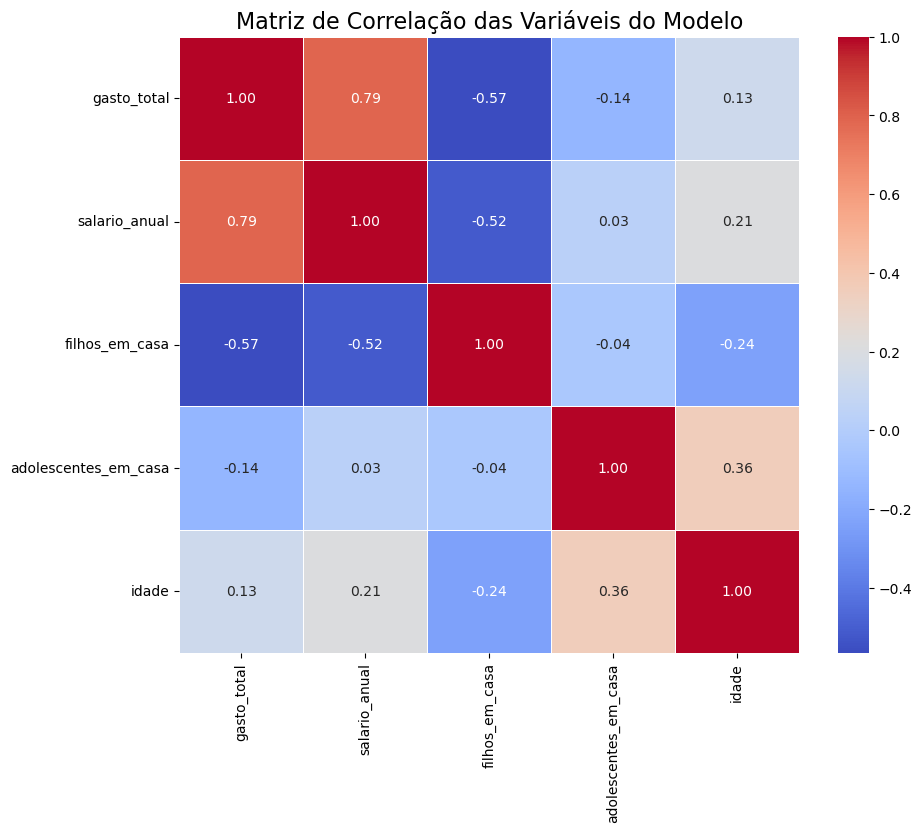

In [29]:
# Visualizando a correlação entre as variaveis quantitativas
variaveis_cor = [
    'gasto_total',
    'salario_anual',
    'filhos_em_casa',
    'adolescentes_em_casa',
    'idade'
]
df_cor = df_reg[variaveis_cor]
matriz_correlacao = df_cor.corr()
print("\n--- Matriz de Correlação ---")
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacao,
    annot= True,
    cmap = 'coolwarm',
    fmt='.2f',           
    linewidths=.5
)

plt.title('Matriz de Correlação das Variáveis do Modelo', fontsize=16)
plt.show()

* Com base na matriz de correlação, vemos que as maiores correlações com o gasto total se dão em duas variáveis: salário anual (Correlação Positiva) e Filhos em casa (Correlação Negativa).
* Para a correlação entre Gasto Total e Salário anual, já foi discorrido que tal comportamento é esperado, uma vez que pessoas com salários mais elevados tendem a consumir mais em montante.
* Além disso, vemos a relação negativa entre Gasto Total e Filhos em Casa, **ou seja, quanto mais filhos em casa, menos esse cliente gasta no total.**
* Outra informação interessante acerca do Gasto Total com outras variáveis é que **adolescentes em casa não têm um impacto negativo tão grande no consumo de nossos clientes**, ou seja, um aumento nos adolescentes em casa tem um impacto negativo no consumo, porém esse impacto é menor se comparado ao impacto da quantidade de filhos em casa do cliente.
* Ademais, vemos que as variáveis explicativas do modelo não possuem grande correlação entre si o que pode demonstrar no cálculo do FIV posteriormente, a não presença de multicolinearidade entre as variáveis explicativas.

## Primeira Regressão (MQO)
Para primeira regressão será utilizada apenas variaveis quantitativas, bem como sera avaliado a qualidade de ajuste da mesma e se ela esta condizente com os hipóteses do modelo classico

A função de regressão a seguir segue o seguinte modelo funcional:
$Y=\ \beta_0+\beta_1\ X_1+\beta_2\ X_2+\beta_3\ X_3+\beta_4\ X_4$
* Onde os coeficientes $\beta_1, \beta_2,\beta_3,\beta_4$ representam os coeficientes angulares das variaveis $X_1,X_2,X_3,X_4$ com $\beta_0$ sendo o intercepto
* Na teoria econômica os betas representam a variação marginal que determinado atributo ou característica exerce influência sobre o a variavel dependente. Entretanto para uma ánalise acurada de tais variaveis, devemos garantir a ausencia da multicolinearidade entre as variaveis.

In [30]:
reg_quant = smf.ols('gasto_total ~ salario_anual + filhos_em_casa + adolescentes_em_casa + idade', data = df_reg).fit()
print(reg_quant.summary())

                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     1078.
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:06:45   Log-Likelihood:                -14312.
No. Observations:                1978   AIC:                         2.863e+04
Df Residuals:                    1973   BIC:                         2.866e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -161.1104 

* Nota-se que a 3 das 4 variaveis foram significativas a 1%, devido a apresentarem p valores iguais ou menores a 0.000.
* Nota-se que o Rquadrado da regressão foi de 0.686, ou seja nossas variaveis explicam 68,6% das variações da variavel dependente
* Entretanto, devemos agora prosseguir para os testes para detectar a presença ou ausência de Multicolinearidade (FIV), Heterocedasticidade (Teste de White)

In [31]:
# Executando o teste do Fator de Inflação da Variância (FIV)
from statsmodels.stats.outliers_influence import variance_inflation_factor

variaveis_independentes = df_reg[['salario_anual', 'filhos_em_casa', 'adolescentes_em_casa', 'idade']]

variaveis_independentes['intercept'] = 1

vif = pd.DataFrame()
vif["variavel"] = variaveis_independentes.columns
vif["VIF"] = [variance_inflation_factor(variaveis_independentes.values, i) for i in range(variaveis_independentes.shape[1])]

print(vif)

               variavel        VIF
0         salario_anual   1.379228
1        filhos_em_casa   1.397691
2  adolescentes_em_casa   1.149728
3                 idade   1.230361
4             intercept  36.531300


C:\Users\vanildo dias da cruz\AppData\Local\Temp\ipykernel_24272\3103068107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variaveis_independentes['intercept'] = 1


* Com base no resultado do FIV ou VIF(Variance inflation factor) podemos notar que as nossas variaveis não apresentam multicolinearidade, uma vez que todas elas, estão proximas de 1

In [32]:
# Executanto o Teste de White para heterocedasticidade
from statsmodels.stats.diagnostic import het_white

# 1. Executa o teste de White
# Passamos os resíduos e a matriz de variáveis explicativas (exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(reg_quant.resid, reg_quant.model.exog)

# 2. Cria um DataFrame para visualizar o resultado bonito
df_white = pd.DataFrame(dict(zip(labels, white_test)), index=['Valores'])

# 3. Exibe o resultado com estilo (opcional)
df_white.style.format("{:.4f}")

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
Valores,964.9314,0.0000,133.5518,0.0000


A metodologia do teste de White consiste nas seguintes hipoteses:
* $H_0$: Os Résiduos são Homocedásticos
* $H_1$: Os Residuos são Heterocedásticos

Se o P-valor for maior que 0.05 aceitamos $H_0$ já se o P-valor for menor que 0.05 rejeitamos $H_0$

**Com base, em nossos resultados, Rejeitamos a Hipótese Nula e assumimos que o modelo tem resíduos heterocedásticos.**

Isso implica que os resíduos não possuem uma variância constante e próxima de zero, dessa forma impactando componentes como:
* Eficiência dos estimadores
* Validade das inferências estatisticas
* Consistência dos erros padrão
* Impacto na previsão

 Dessa forma, temos duas opções diante desse cenário: a primeira, logaritmizar a variável Gasto Total e Salário Anual, uma vez que normalmente essas variáveis podem apresentar um crescimento exponencial por serem dados financeiros. E o segundo é aplicar o Método dos Minimos Quadrados Generalizados (MQG), do qual consiste em ponderar cada observação da amostra 


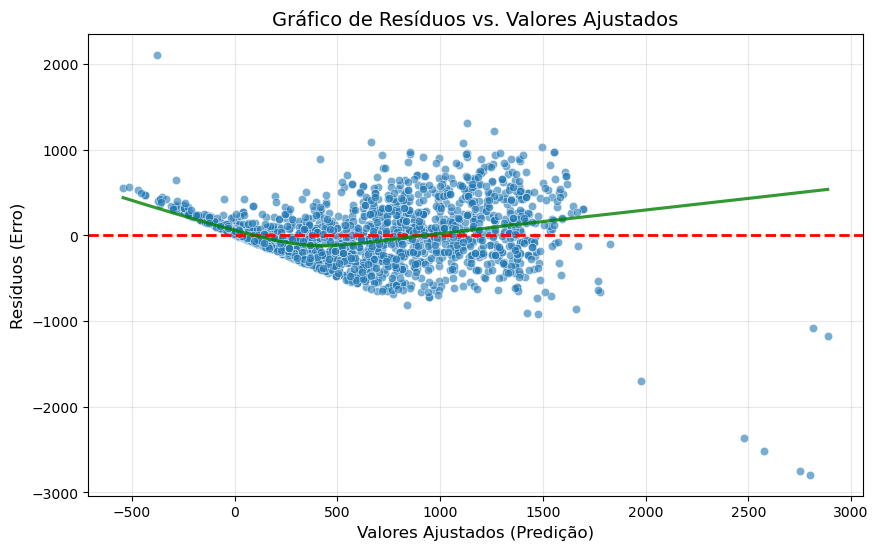

In [33]:
# Exibição de gráfico Resíduos x Valores Preditos
plt.figure(figsize=(10, 6))

# 1. Plotar os pontos (Scatter Plot)
sns.scatterplot(x=reg_quant.fittedvalues, y=reg_quant.resid, alpha=0.6)

# 2. Adicionar linha de referência no Zero (onde o erro é nulo)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 3.Adicionar uma linha de tendência suave para ver se há curvatura
sns.regplot(x=reg_quant.fittedvalues, y=reg_quant.resid, 
            scatter=False, ci=False, lowess=True, 
            line_kws={'color': 'green', 'alpha': 0.8})

# Estilização
plt.title('Gráfico de Resíduos vs. Valores Ajustados', fontsize=14)
plt.xlabel('Valores Ajustados (Predição)', fontsize=12)
plt.ylabel('Resíduos (Erro)', fontsize=12)
plt.grid(True, alpha=0.3)

# Exibir
plt.show()

No gráfico podemos visualizar algo que foi confirmado pelo teste de White, aonde os erros não seguem uma variancia constante e proximo de 0, bem como apresenta uma curvatura leve em formato de "U" o que acaba impactando na predição das variaveis do modelo.


In [34]:
# Regressão Utilizando Log
df_reg['log_gasto_total'] = np.log(df_reg['gasto_total'] + 1)
df_reg['log_salario_anual'] = np.log(df_reg['salario_anual'] + 1)
reg_log = smf.ols('log_gasto_total ~ log_salario_anual + filhos_em_casa + adolescentes_em_casa + idade', data=df_reg).fit()

print(reg_log.summary())

                            OLS Regression Results                            
Dep. Variable:        log_gasto_total   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     995.4
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:06:46   Log-Likelihood:                -2479.9
No. Observations:                1978   AIC:                             4970.
Df Residuals:                    1973   BIC:                             4998.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -13.3552 

In [35]:
# Testando heterocedasticidade para o modelo log
# 1. Executa o teste de White
# Passamos os resíduos e a matriz de variáveis explicativas (exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(reg_log.resid, reg_log.model.exog)

# 2. Cria um DataFrame para visualizar o resultado
df_white = pd.DataFrame(dict(zip(labels, white_test)), index=['Valores'])

# 3. Exibe o resultado com estilo
df_white.style.format("{:.4f}")

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
Valores,370.0402,0.0000,32.2676,0.0000


O problema persiste ainda que utilizando as variaveis Gasto Total e Salario Anual em Logaritmo, o que nos leva a optarmos pela segunda opção, a utilização de um modelo MQG/MQP

## Segunda Regressão (WLS)

In [36]:
# Modelo utilizando MQG ou Minimos Quadrados Ponderados (MQP)
log_resid_sq = np.log(reg_quant.resid ** 2)

modelo_var = smf.ols('log_resid_sq ~ salario_anual + filhos_em_casa + adolescentes_em_casa + idade', data=df_reg).fit()

variancia_estimada = np.exp(modelo_var.fittedvalues)
pesos = 1 / variancia_estimada

modelo_mqg = smf.wls('gasto_total ~ salario_anual + filhos_em_casa + adolescentes_em_casa + idade', 
                     data=df_reg, 
                     weights=pesos).fit()

print(modelo_mqg.summary())

                            WLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.652
Model:                            WLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     925.7
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:06:46   Log-Likelihood:                -14046.
No. Observations:                1978   AIC:                         2.810e+04
Df Residuals:                    1973   BIC:                         2.813e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -169.2597 

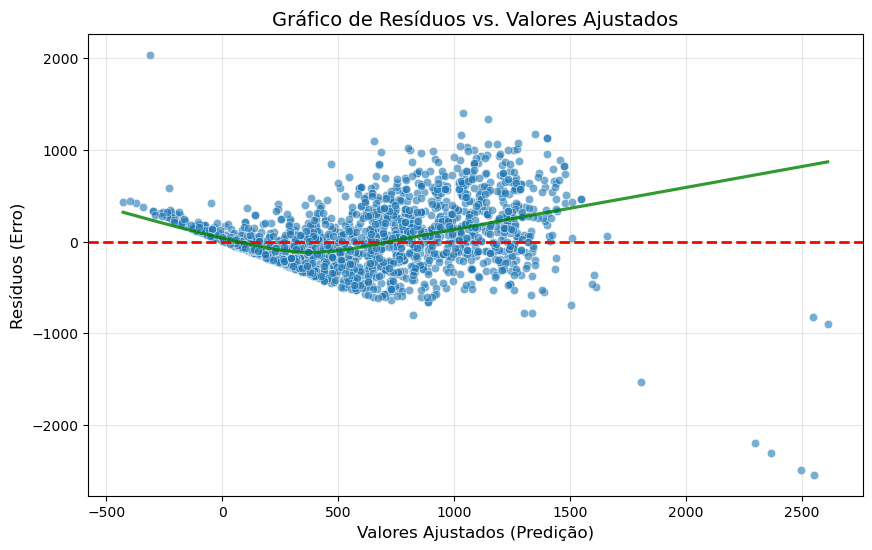

In [37]:
# Exibição de gráfico Resíduos x Valores Preditos
plt.figure(figsize=(10, 6))

# 1. Plotar os pontos (Scatter Plot)
sns.scatterplot(x=modelo_mqg.fittedvalues, y=modelo_mqg.resid, alpha=0.6)

# 2. Adicionar linha de referência no Zero (onde o erro é nulo)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 3.Adicionar uma linha de tendência suave para ver se há curvatura
sns.regplot(x=modelo_mqg.fittedvalues, y=modelo_mqg.resid, 
            scatter=False, ci=False, lowess=True, 
            line_kws={'color': 'green', 'alpha': 0.8})

# Estilização
plt.title('Gráfico de Resíduos vs. Valores Ajustados', fontsize=14)
plt.xlabel('Valores Ajustados (Predição)', fontsize=12)
plt.ylabel('Resíduos (Erro)', fontsize=12)
plt.grid(True, alpha=0.3)

# Exibição
plt.show()

In [38]:
# Teste de White para o modelo WLS
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(modelo_mqg.resid, modelo_mqg.model.exog)

# 2. Cria um DataFrame para visualizar o resultado
df_white = pd.DataFrame(dict(zip(labels, white_test)), index=['Valores'])

# 3. Exibição  do resultado 
df_white.style.format("{:.4f}")

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
Valores,849.7993,0.0000,105.6142,0.0000


In [39]:
# Modelo WLS com Erros Robustos
modelo_wls_robusto = smf.wls('gasto_total ~ salario_anual + filhos_em_casa + adolescentes_em_casa + idade', 
                          data=df_reg, 
                          weights=pesos).fit(cov_type='HC3')

print(modelo_wls_robusto.summary())

                            WLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.652
Model:                            WLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     413.5
Date:                Mon, 05 Jan 2026   Prob (F-statistic):          6.71e-259
Time:                        16:06:46   Log-Likelihood:                -14046.
No. Observations:                1978   AIC:                         2.810e+04
Df Residuals:                    1973   BIC:                         2.813e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -169.2597 

In [40]:
# Teste de White WLS - Erros Robustos
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(modelo_wls_robusto.resid, modelo_wls_robusto.model.exog)

# 2. Cria um DataFrame para visualizar o resultado
df_white = pd.DataFrame(dict(zip(labels, white_test)), index=['Valores'])

# 3. Exibição  do resultado 
df_white.style.format("{:.4f}")

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
Valores,849.7993,0.0000,105.6142,0.0000


Nota-se que, com base nas regressões WLS e WLS - Erros Robustos, não foi possível corrigir a heterocedasticidade, Tal problema tem um impacto direto na finalidade da regressão para o estudo do departamento de marketing, que é a previsão do gasto total do cliente.

Por fim, podemos ainda tentar adicionar variáveis categóricas em forma de dummies, com a intenção de reduzir a heterocedasticidade no modelo, entretanto, dado os resultados até aqui, não é esperada uma melhora significativa.

In [41]:
reg_categoricas = smf.ols('gasto_total ~ filhos_em_casa + adolescentes_em_casa + idade + C(estado_civil) + C(escolaridade) + C(geracao)', data = df_reg).fit()

print(reg_categoricas.summary())

                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     96.29
Date:                Mon, 05 Jan 2026   Prob (F-statistic):          2.51e-187
Time:                        16:06:46   Log-Likelihood:                -15000.
No. Observations:                1978   AIC:                         3.003e+04
Df Residuals:                    1965   BIC:                         3.010e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [42]:
# Teste de White OLS categoricos 
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(reg_categoricas.resid, reg_categoricas.model.exog)

# 2. Cria um DataFrame para visualizar o resultado
df_white = pd.DataFrame(dict(zip(labels, white_test)), index=['Valores'])

# 3. Exibição  do resultado 
df_white.style.format("{:.4f}")

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
Valores,329.5927,0.0000,5.7000,0.0000


## Conclusões acerca dos modelos de previsão por Regressão Linear Multipla
As regressões se mostraram insuficientes para o fim de predizer o gasto total, devido à presença de heterocedasticidade no modelo. Isso pode acontecer devido à má especificação, presença de informações aberrantes (Outliers) ou também ao fato de que pessoas com renda maior possuem maior liberdade para alocação da renda, dessa forma possuindo maior variância em seus gastos. Desse modo, pode ser que haja clientes com uma renda muito elevada na base de dados dos clientes e que, por conseguinte, possuem um gasto total baixo. O que poderia ser um indicativo de um cliente pontual da empresa, entretanto, para afirmarmos isso, seria necessário solicitar novos dados à equipe de marketing a fim de auferir a frequência, ou a quantidade de compras que cada cliente efetou na empresa, e não somente o somatório de seu gasto por categoria ou gasto total.

Por isso, optaremos pela não utilização do modelo pela equipe de marketing com base nos dados disponíveis até aqui, podendo futuramente, com novos dados, a tentativa de uma nova predição, ou até mesmo utilização de modelos como ARCH. Porém, podemos concluir que o fator elasticidade - renda é alto, com clientes com renda mais alta possuindo gastos médios maiores na loja.

Ademais, com base na tabela de correlação, podemos ver sim que há uma tendência positiva entre maiores salários se tornarem um gasto total maior, bem como há também uma correlação negativa mais fraca em torno de 0.5 e 0.55 entre o gasto total e o número de filhos em casa, indicando que clientes com mais filhos em casa possuem um gasto total dos nossos serviços mais baixo.


# **3 - Perfil do cliente por meio de canal de venda**

In [43]:
# Criando um dataframe para analises necessarias
df_meios_de_vendas = df[['ano_nascimento', 'escolaridade', 'estado_civil', 'salario_anual','filhos_em_casa', 'adolescentes_em_casa','gasto_com_eletronicos',
       'gasto_com_brinquedos', 'gasto_com_moveis', 'gasto_com_utilidades',
       'gasto_com_alimentos', 'gasto_com_vestuario','numero_de_compras_na_web',
        'numero_de_compras_via_catalogo', 'numero_de_compras_na_loja','numero_visitas_website_mes','pais']].copy()

## Meios de compra por Escolaridade do cliente

In [44]:
# Tabela de meio de compra por Escolaridade do cliente
colunas_a_exibir = ['numero_de_compras_na_web', 'numero_de_compras_via_catalogo','numero_de_compras_na_loja']
tabela_escolaridade = df_meios_de_vendas.groupby('escolaridade')[colunas_a_exibir].sum().reset_index()

# Ordenando a visualização
tabela_escolaridade =  tabela_escolaridade.sort_values('escolaridade',ascending= True) # Ordenando por ordem alfabetica em escolaridade
#Criando a soma total
soma = tabela_escolaridade[colunas_a_exibir].sum().to_frame().T
soma['escolaridade']= 'Total'

tabela_escolaridade_f = pd.concat([tabela_escolaridade,soma],ignore_index=True)
# Criando um dicionario para nomear as colunas
visualização = {
    'numero_de_compras_na_web': 'Qtd de Compras na Web',
    'numero_de_compras_via_catalogo': 'Qtd de Compra por Catalogo',
    'numero_de_compras_na_loja': 'Qtd de Compras na Loja'
}

colunas_novas = list(visualização.values())

print("Meio de canal de vendas agrupado por Escolaridade")
# Visualização dos resultados
tabela_escolaridade_f.rename(columns=visualização)\
            .style.format('{:.0f}', subset=colunas_novas) \
            .background_gradient(cmap='RdYlGn', subset=(tabela_escolaridade_f.index[:-1], colunas_novas)) \
            .map(lambda x: 'font-weight: bold', subset=(tabela_escolaridade_f.index[-1:], colunas_novas))

Meio de canal de vendas agrupado por Escolaridade


,escolaridade,Qtd de Compras na Web,Qtd de Compra por Catalogo,Qtd de Compras na Loja
0,Curso Superior,4124,2737,5813
1,Doutorado,1895,1217,2639
2,Mestrado,1375,860,2006
3,Primeiro Grau,83,21,133
4,Segundo Grau,665,429,995
5,Total,8142,5264,11586


* Nota-se que os principais meios de compras são ordenados em Loja, Web e Catalogo, respectivamente.
* Fica evidente que todas as escolaridades possuem uma preferência em compras na Loja, o que pode denotar uma preferência dos consumidores para adquirirem uma certa **consultoria na hora de comprar produtos**, uma vez que clientes que possuem preferência por comprar em lojas esperam fazer uma compra mais embasada, bem como testar o produto no local, diferentemente de quem compra online que muitas vezes já conhece o produto e assim pretende pagar menos, uma vez que não se faz necessário o processo de consultoria
* Também, nota-se uma certa importância das compras por catálogo, o que normalmente implica também ao menos um contato do vendedor na hora de efetuar um pagamento, **o que novamente reforça a preferência dos nossos clientes por maior contato humano**, este que pode estar atrelado a justamente ao produto mais vendido pela empresa que consiste em eletrônicos, uma vez que tais itens podem ser considerados bens bastante heterogêneos, o que faz o cliente necessitar de maior auxílio para realizar a compra do produto
* *Para as análises subsequentes acerca dos canais de vendas, são esperados resultados semelhantes*.

## Meios de compras por Geração do cliente

In [45]:
# Criando a coluna idade
df_meios_de_vendas['idade'] = 2025 - df_meios_de_vendas['ano_nascimento']
# Aplicando a função de geração
df_meios_de_vendas['geracao'] = df_meios_de_vendas['ano_nascimento'].apply(definir_geracao)

In [46]:
# Tabela de meio de compra por Geração do cliente
tabela_geracao = df_meios_de_vendas.groupby('geracao')[colunas_a_exibir].sum().reset_index()

#Criando Soma do total
soma = tabela_geracao[colunas_a_exibir].sum().to_frame().T
soma['geracao'] = 'Total'

tabela_geracao_f = pd.concat([tabela_geracao,soma],ignore_index=True)

# Visualização dos resultados
tabela_geracao_f.rename(columns=visualização)\
            .style.format('{:.0f}', subset=colunas_novas) \
            .background_gradient(cmap='RdYlGn', subset=(tabela_geracao_f.index[:-1], colunas_novas)) \
            .map(lambda x: 'font-weight: bold', subset=(tabela_geracao_f.index[-1:], colunas_novas))

,geracao,Qtd de Compras na Web,Qtd de Compra por Catalogo,Qtd de Compras na Loja
0,Baby Boomers,3026,2175,4367
1,Geração X,3793,2164,5247
2,Millennials,1170,813,1802
3,Veteranos,153,112,170
4,Total,8142,5264,11586


* Nota-se também comportamento semelhante ao elucidado quando olhamos pelo prisma da escolaridade.
* Vemos que todas as gerações compram mais na loja se comparado a outros métodos, bem como segue-se a **preferência de Loja > Web > Catálogo.**
* **A única geração que tende a comprar quase a mesma quantidade, seja em web e loja, é a de veteranos.**

## Meios de compras por País do cliente

In [47]:
# Tabela de meio de compra por País do Cliente
tabela_pais = df_meios_de_vendas.groupby('pais')[colunas_a_exibir].sum().reset_index()

# Criando soma do total
soma = tabela_pais[colunas_a_exibir].sum().to_frame().T
soma['pais'] = 'Total'

tabela_pais_f = pd.concat([tabela_pais,soma],ignore_index=True)
# Visualização dos resultados
tabela_pais_f.rename(columns=visualização)\
            .style.format('{:.0f}',subset=colunas_novas) \
            .background_gradient(cmap='RdYlGn', subset=(tabela_pais_f.index[:-1],colunas_novas)) \
            .map(lambda x: 'font-weight: bold', subset=(tabela_pais_f.index[-1:],colunas_novas))

,pais,Qtd de Compras na Web,Qtd de Compra por Catalogo,Qtd de Compras na Loja
0,Alemanha,410,264,617
1,Argentina,538,318,719
2,Brasil,590,386,807
3,Chile,1040,646,1442
4,Espanha,1258,805,1768
5,Estados Unidos,3882,2547,5672
6,Portugal,424,298,561
7,Total,8142,5264,11586


* Olhando pela ótica da categoria país do cliente, também observamos a mesma dinâmica
* Nenhum dos países possui clientes que compram mais na web se comparado a compras na loja, bem como segue-se o mesmo ordenamento de preferência elencado pelas categorias Escolaridade e geração do cliente.

## Conclusões acerca dos meios de compras dos clientes

* Podemos concluir que os clientes têm uma **preferência no geral bem definida por Loja > Web > Catálogo**, dessa forma se faz necessário para a empresa focar na qualidade do atendimento na loja, com o marketing podendo avaliar a criação de jornadas dos clientes e treinamento para os vendedores oferecerem um serviço de atendimento diferenciado. Algo que empresas de eletrônicos têm como foco grande, uma vez que isso pode ser fator chave para o cliente decidir comprar na nossa loja e não a de uma concorrente.
* Ademais, nota-se que **a maioria dos clientes prefere ter algum contato com o vendedor**, nem que seja somente na fase de pagamento, como nas compras via catálogo, o que reforça ainda mais a característica do consumidor da empresa, ainda pela preferência de uma compra auxiliada pelos consultores de vendas. O que demonstra que **nossos clientes ainda não estão dispostos a comprar de maneira completamente autônoma**, sem uma equipe de consultores de vendas.
* Tais características devem pautar as estratégias de marketing futuras, a fim de realizar estratégias mais direcionadas para o perfil do público. Bem como, direcionar as estratégias para um **foco maior no atendimento e jornada do cliente**, uma vez que isso fideliza o cliente e o faz retornar a comprar novamente.

# **4 - Campanhas de Vendas e sua Efetividade**

In [48]:
# Criando o df especifico para a analise das campanhas
colunas_campanhas = ['ano_nascimento', 'escolaridade', 'estado_civil', 'salario_anual',
       'filhos_em_casa', 'adolescentes_em_casa','compra_na_campanha_1',
       'compra_na_campanha_2', 'compra_na_campanha_3', 'compra_na_campanha_4',
       'compra_na_campanha_5', 'comprou']
#Criação do DF
df_campanhas = df[colunas_campanhas].copy()
# Anexando a segmentação dos clientes ao data frame de campanhas
df_campanhas['segmentação'] = df_clientes['Nome_Cluster']
df_campanhas['gasto_total'] = df_clientes['gasto_total']
df_campanhas['geracao'] = df_campanhas['ano_nascimento'].apply(definir_geracao)
df_campanhas.columns

Index(['ano_nascimento', 'escolaridade', 'estado_civil', 'salario_anual',
       'filhos_em_casa', 'adolescentes_em_casa', 'compra_na_campanha_1',
       'compra_na_campanha_2', 'compra_na_campanha_3', 'compra_na_campanha_4',
       'compra_na_campanha_5', 'comprou', 'segmentação', 'gasto_total',
       'geracao'],
      dtype='object')

In [49]:
# Analisando a quantidade de compras por campanha
campanhas = ['compra_na_campanha_1',
       'compra_na_campanha_2', 'compra_na_campanha_3', 'compra_na_campanha_4',
       'compra_na_campanha_5']
# Criação da tabela de campanhas
tabela_campanhas = df_campanhas[campanhas].sum().reset_index()
# Ordenamento
tabela_campanhas.sort_values('index',ascending=False)
tabela_campanhas

,index,0
0,compra_na_campanha_1,148
1,compra_na_campanha_2,146
2,compra_na_campanha_3,142
3,compra_na_campanha_4,133
4,compra_na_campanha_5,26


Nota-se que a campanha 1 foi a que gerou mais compras, bem como a campanha 5 teve um desempenho muito abaixo das outras campanhas

## Campanhas de vendas e gasto total Médio

In [50]:
# Criando tabela com o ticket médio de quem aceitou as campanhas
resultados = []
# Filtra quem aceitou as campanhas
for campanha in campanhas:
    filtro =  df_campanhas[df_campanhas[campanha]==1]

# Calculo das métricas
    ticket_medio =filtro['gasto_total'].mean()
    qtd_clientes = filtro.shape[0]
#Guardando em dicionario
    resultados.append({
        'Campanha': campanha.replace('compra_na_', '').replace('_', ' ').title(),
        'Ticket Médio': ticket_medio,
        'Qtd Clientes': qtd_clientes
    })

tabela_campanhas_tkm = pd.DataFrame(resultados).sort_values('Ticket Médio', ascending=False)
# Exibição
tabela_campanhas_tkm.style.format({'Ticket Médio': 'R$ {:,.2f}'}) \
                    .background_gradient(cmap='Greens', subset='Ticket Médio')

,Campanha,Ticket Médio,Qtd Clientes
2,Campanha 3,"R$ 1,624.08",142
3,Campanha 4,"R$ 1,482.44",133
4,Campanha 5,"R$ 1,294.12",26
1,Campanha 2,"R$ 1,155.00",146
0,Campanha 1,R$ 691.84,148


Vale ressaltar que o Ticket Médio em questão não corresponde ao gasto do cliente na campanha específica, mas sim seu gasto total como consumidor da empresa. Dessa forma, podemos analisar a campanha pela visão de ticket médio da seguinte maneira.

* A campanha 3 foi a que atraiu consumidores que possuem gastos totais mais altos.
* A campanha 4 também trouxe consumidores com gastos totais mais elevados, apesar de figurar um gasto menor se comparada à campanha 3.
* A campanha 1 foi a que mais gerou compras por parte de clientes, **entretanto, foi a que mais atraiu consumidores com um gasto médio baixo,** se distanciando dos valores das outras campanhas.

Com base nisso, vemos que a Campanha 3 e 4 atraiu um público que tem um gasto total na loja alto, seja porque consome mais ou tem um consumo mais constante na mesma. Com as campanhas 5 e 2 atraindo um público que tem um gasto médio ainda alto na loja, mas menor se comparado aos públicos de 3 e 4. Por fim, a campanha 1 atraiu um público comprador cujos gastos totais são mais modestos se comparados aos públicos das outras campanhas.

## Campanhas de vendas e geração do cliente
Busca-se responder a pergunta qual é a geração que mais comprou em cada campanha?

In [51]:
# Criando a tabela com a compra em cada campanha por geração
tabela_campanhas_geracao = df_campanhas.groupby('geracao')[campanhas].sum().reset_index()
#Ordenando a tabela com base na geração
ordenamento = ['Veteranos','Baby Boomers','Geração X','Millennials']
tabela_campanhas_geracao['geracao'] = pd.Categorical(
    tabela_campanhas_geracao['geracao'],
    categories=ordenamento,
    ordered=True
)
tabela_campanhas_geracao = tabela_campanhas_geracao.sort_values('geracao')
# Criando dicionário com melhor leitura para as colunas
visualização = {
    'compra_na_campanha_1': 'Qtd Compras Campanha 1',
    'compra_na_campanha_2': 'Qtd Compras Campanha 2',
    'compra_na_campanha_3': 'Qtd Compras Campanha 3',
    'compra_na_campanha_4': 'Qtd Compras Campanha 4',
    'compra_na_campanha_5': 'Qtd Compras Campanha 5'
}
# Estilização
tabela_campanhas_geracao.rename(columns=visualização)\
.rename_axis('Geração')\
.style.background_gradient(cmap='Greens')

,geracao,Qtd Compras Campanha 1,Qtd Compras Campanha 2,Qtd Compras Campanha 3,Qtd Compras Campanha 4,Qtd Compras Campanha 5
Geração,,,,,,
3,Veteranos,3,2,4,2,0
0,Baby Boomers,37,62,47,56,13
1,Geração X,71,61,51,44,9
2,Millennials,37,21,40,31,4


Podemos notar as seguintes características sobre as campanhas.
* A Campanha 1 teve mais aderência para a geração X
* A Campanha 2 e 3 teve aderência maior para os Baby Boomers e Geração X
* A Campanha 4 e 5 também teve uma aderência maior para a geração X e Baby Boomers

Desse modo, notamos quais campanhas, com base nas pessoas que compraram, obtiveram um maior impacto na nossa base de clientes.

## Campanhas de vendas por Escolaridade do Cliente

In [52]:
# Criando a tabela com a compra em cada campanha por escolaridade
tabela_campanhas_escolaridade = df_campanhas.groupby('escolaridade')[campanhas].sum().reset_index()
#Ordenando a tabela com base na escolaridade da mais alta para a mais baixa
ordenamento = ['Doutorado','Mestrado','Curso Superior','Segundo Grau', 'Primeiro Grau']
tabela_campanhas_escolaridade['escolaridade'] = pd.Categorical(
    tabela_campanhas_escolaridade['escolaridade'],
    categories=ordenamento,
    ordered=True
)
tabela_campanhas_escolaridade = tabela_campanhas_escolaridade.sort_values('escolaridade')

#Estilização
tabela_campanhas_escolaridade.rename(columns=visualização)\
.rename_axis('Escolaridade')\
.style.background_gradient(cmap='Greens')

,escolaridade,Qtd Compras Campanha 1,Qtd Compras Campanha 2,Qtd Compras Campanha 3,Qtd Compras Campanha 4,Qtd Compras Campanha 5
Escolaridade,,,,,,
1,Doutorado,36,40,31,30,10
2,Mestrado,20,29,27,16,1
0,Curso Superior,72,68,75,73,14
4,Segundo Grau,14,9,9,14,1
3,Primeiro Grau,6,0,0,0,0


Com base na tabela, vemos que em todas as campanhas a maior adesão por escolaridade foi de pessoas com Curso Superior, entretanto isso é esperado, uma vez que nossos clientes majoritariamente possuem curso superior. Ademais, vemos as seguintes características também:
* A campanha 2 e 1 tiveram adesão maior por parte de Doutorados.
* As Campanhas 2 e 3 tiveram adesão maior por parte de Mestres.
* As escolaridades Segundo e Primeiro Grau não aderiram muito às campanhas.

## Campanhas de vendas por Segmento do Cliente

In [53]:
# Criando a tabela com a compra em cada campanha por segmento do cliente
tabela_campanhas_segmento = df_campanhas.groupby('segmentação')[campanhas].sum().reset_index()
# Ordenando a tabela com base no Segmento do cliente
ordenamento = ['Platinum','Gold','Silver','Bronze']
tabela_campanhas_segmento['segmentação'] = pd.Categorical(
    tabela_campanhas_segmento['segmentação'],
    categories=ordenamento,
    ordered=True    
)
tabela_campanhas_segmento = tabela_campanhas_segmento.sort_values('segmentação')

# Estilização
tabela_campanhas_segmento.rename(columns=visualização)\
.rename_axis('Segmentação')\
.style.background_gradient(cmap='Greens')

,segmentação,Qtd Compras Campanha 1,Qtd Compras Campanha 2,Qtd Compras Campanha 3,Qtd Compras Campanha 4,Qtd Compras Campanha 5
Segmentação,,,,,,
2,Platinum,47,88,138,118,20
1,Gold,28,40,3,8,4
3,Silver,23,15,0,3,2
0,Bronze,50,1,0,2,0


Ao analisarmos a tabela de seguimento dos clientes com a tabela de campanhas por ticket médio, realizamos insights valiosos sobre cada uma:
* A Campanha 1 foi a que possuiu menor ticket médio, parte disso se deu devido à adesão majoritária na campanha por clientes do segmento Bronze, dos quais possuem um gasto médio e salário médio anual menor. Dessa forma, "puxaram" o ticket médio da campanha 1 para baixo, entretanto vale ressaltar que essa campanha também teve adesão por parte de clientes do segmento Platinum, entretanto isso não foi suficiente para aumentar o ticket médio da mesma.
* A Campanha 2 teve uma adesão majoritária por clientes do segmento Platinum e Gold, o que explica essa campanha ter atraído um público que possui um ticket médio mais distante se comparado à campanha 1.
* As Campanhas 3, 4 e 5 foram campanhas que atraíram de maneira substancial os clientes do segmento Platinum, o que explica o ticket médio mais elevado de todas, especialmente a campanha 3. Dessa forma, essas campanhas foram mais efetivas para atrair um público que possui um gasto médio mais alto.


## Conclusões sobre as campanhas de vendas

* **A campanha 1 teve uma adesão maior com os clientes do segmento Bronze,** o que explica seu baixo ticket médio, o que pode indicar que as táticas utilizadas pelo marketing nesta campanha **conseguiram atingir esse público**, o que não aconteceu nas campanhas posteriores, Dessa forma, o marketing pode utilizar as táticas utilizadas nesta campanha para campanhas futuras direcionadas a esse segmento de clientes. Ademais, atraiu majoritariamente clientes da Geração X.
* A campanha 2 teve uma adesão maior do segmento de clientes Platinum, **mas com presença substancial do segmento Gold, sendo a campanha que mais atraiu esse segmento de clientes**. Dessa forma, as táticas de marketing utilizadas na mesma, podem ser utilizadas no futuro para atrair os clientes do segmento Gold, uma vez que as campanhas 3,4,5 não foram efetivas para trazer tais clientes, bem como a campanha 1 teve uma efetividade maior no segmento Bronze. Ademais, a campanha 2 também teve uma adesão maior pelas gerações Baby Boomer e X.
* **A campanha 3 foi indubitavelmente a mais efetiva para a adesão do segmento Platinum**, com esse segmento representando quase a totalidade de clientes que compraram na campanha. Por tal motivo mesmo, ela foi a que obteve os clientes com maiores gastos médios na loja, dessa forma atraindo um público High Ticket. Desse modo, o marketing deve estudar as táticas utilizadas na mesma a fim de utilizar em futuras campanhas cujo objetivo seja atrair públicos com gastos médios maiores. Além disso, a campanha foi aderida significativamente pela Geração X, Baby Boomers e Millennials, com os últimos sendo essa a campanha com maior participação dessa geração.
* A Campanha 4 também se destaca pela adesão substancial daqueles que compraram na campanha e fazem parte do segmento Platinum, **caracterizando essa campanha também como uma campanha atrativa para clientes com gastos médios mais altos**, mas que obteve um ticket médio menor se comparado com a campanha 3. Bem como, tal campanha teve uma adesão maior dos Baby Boomers se comparado à Geração X.
* Por fim, a campanha 5 foi de todas as campanhas a que teve a menor adesão de clientes no total, totalizando 26 clientes que compraram durante a campanha. Entretanto, a mesma também se caracterizou por uma predominância de clientes do segmento Platinum, além disso, foi uma campanha com uma presença predominante entre pessoas com Curso Superior e Doutorado.
* Vemos também que o segmento Platinum é predominante em quase todas as campanhas de marketing, o que pode denotar que esse grupo prefere comprar os itens com certos descontos, ou é mais propenso a consumir quando os itens estão com desconto. Podemos validar essa hipótese mais à frente.

## Compras com desconto e média de dias desde ultima compra

In [54]:
# Adicionando as colunas necessárias para ánalise
df_campanhas['numero_de_compras_com_desconto'] = df['numero_de_compras_com_desconto']
df_campanhas['dias_desde_ultima_compra'] = df['dias_desde_ultima_compra']

In [55]:
# Criando tabela com o numero de compras do cliente com desconto por segmento do cliente
tabela_desconto_segmento = df_campanhas.groupby('segmentação')['numero_de_compras_com_desconto'].sum().reset_index()
# Ordenando a tabela do maior numero para o menor
tabela_desconto_segmento = tabela_desconto_segmento.sort_values('numero_de_compras_com_desconto',ascending=False)
# Estilização
tabela_desconto_segmento.style.background_gradient(cmap='Greens')

,segmentação,numero_de_compras_com_desconto
3,Silver,1401
1,Gold,1118
2,Platinum,1046
0,Bronze,1043


Com base na tabela acima, podemos concluir que os clientes que mais compram itens com desconto são do segmento Silver com 1401 compras. Seguido do segmento Gold com 1118 compras. Dessa forma, vemos que o segmento Platinum não é o segmento que tem mais preferência por comprar com desconto.

In [56]:
# Criando tabela com o numero médio de dias que o cliente não comprou na loja por segmento
tabela_dias_sem_comprar = df_campanhas.groupby('segmentação')['dias_desde_ultima_compra'].mean().reset_index()
# Ordenando a tabela do maior para o menor
tabela_dias_sem_comprar = tabela_dias_sem_comprar.sort_values('dias_desde_ultima_compra',ascending=False)
# Estilização
tabela_dias_sem_comprar.style.format({'dias_desde_ultima_compra': '{:.2f}'}).background_gradient(cmap='Greens')

,segmentação,dias_desde_ultima_compra
3,Silver,44.35
2,Platinum,44.01
0,Bronze,43.30
1,Gold,43.06


Também notamos que em todos os segmentos temos uma média de dias desde a última compra de cerca de 44 a 43 dias. O que pode implicar que essa seja também uma média de dias para todos os clientes da nossa loja.

In [57]:
# Calculo da médio de dias desde a ultima compra
print('Média de dias desde a ultima compra')
print(round(df_campanhas['dias_desde_ultima_compra'].mean(),2))

Média de dias desde a ultima compra
43.76


# **5 - Limitações**

Por fim, podemos ressaltar algumas limitações da presente análise advindas da limitação de características dos dados:
* Na seção 1 temos: Impossibilidade de atestar a frequência de compras dos clientes, ou seja, a quantidade de vezes que compraram na loja e o valor comprado em cada uma. Bem como de inferir se a quantidade de compras em determinadas categorias de produto é maior que as outras, uma vez que é esperado um valor monetário maior para eletrônicos se comparado a brinquedos, por exemplo.
* Na seção 2 temos: Impossibilidade de utilizar a regressão para fins de predição do gasto do cliente.
* Na seção 4 temos: Impossibilidade de ver a receita que cada campanha efetivamente trouxe a loja, bem como os gastos individuais que cada cliente realizou em cada campanha.

Desse modo, é solicitado ao departamento de marketing a base de dados com os IDs de transação/pedidos dos clientes de maneira individual, uma vez que isso poderá aprofundar a presente análise e mitigar grande parte das limitações.

# **6 - Resumo Executivo**

* Concluímos que a maior parte dos nossos clientes são pessoas com Graduação, da geração X e Baby Boomers, Solteiros e sem filhos ou adolescentes em casa e localizados nos Estados Unidos da América. Tal informação pode orientar as campanhas de marketing futuras, para a criação de personas.
* O público com maior gasto total na loja é composto por pessoas com Curso Superior e com rendas anuais altas, sendo assim um público com ticket mais alto que pode maximizar receita de futuras campanhas de marketing.
* Os maiores segmentos de clientes da nossa loja se encontram, pela ordem de quantidade, em: Platinum, Bronze, Gold e Silver. Com o Segmento Platinum figurando em um gasto médio total muito à frente de outros segmentos.
* A maioria dos nossos clientes prefere comprar por Loja ou Cátalogo. O que implica em mantermos estratégias de jornadas do cliente robustas e eficazes, bem como consultores de vendas competentes, uma vez que os nossos consumidores preferem ter em algum momento contato com os mesmos.
* A Campanha 1 foi efetiva para atrair parte dos consumidores do segmento Bronze. A campanha 2 é para atrair clientes do segmento Gold. Com as campanhas 3 e 4 atraindo um número alto de clientes do segmento Platinum.
* O Segmento Silver foi o que mais realizou compras com desconto
* A média de dias sem compra na base de clientes é de cerca de 44 dias.

Dessa forma, é orientado ao Marketing. O foco no segmento Platinum para captação de receitas maiores, uma vez que tais clientes são a maioria, bem como possuem um ticket médio maior. Além de eles se mostrarem mais propensos às campanhas. Ademais, estabelecer e continuamente aprimorar a jornada do cliente devido à predisposição de nossos clientes por comprar com consultores de vendas. Também devem ser instruídas algumas características da  persona de nosso cliente que compõem pessoas da geração X ou Baby Boomer, solteiros, sem filhos ou adolescentes em casa e com Curso Superior (Graduação) em sua maioria. Ademais, foi constatado que um dos fatores mais importantes para o gasto total do cliente na loja é justamente seu salário anual, com ambos possuindo uma correlação forte e positiva.

